# Pratica 5 — Transformers and LLMs for Text Classification

This notebook has two parts:

- **Part 1** — Build and train a Transformer classifier on the IMDb sentiment dataset
- **Part 2** — Use a large language model (LLaMA via Groq) for zero-shot and few-shot classification

**Dataset (Part 1):** IMDb — 25 000 train / 25 000 test, binary sentiment (0 = negative, 1 = positive)  
**Dataset (Part 2):** IMDb — same, but we only send a handful of examples to the LLM API

---
# Part 1 — Transformer for Text Classification

## 1.1 Recap: the Transformer building blocks

In the theory class we saw the core building blocks (code in `transformer-ex.py`):

| Component | Role |
|---|---|
| **SelfAttention** | Scaled dot-product attention — one head |
| **MultiHeadAttention** | Several heads in parallel, outputs concatenated + linear projection |
| **FeedForward** | Two-layer MLP inside each block |
| **TransformerBlock** | Attention → residual+norm → FF → residual+norm |
| **PositionalEncoding** | Adds positional signal to embeddings (sin/cos) |

For classification we only need the **encoder** part: the input is a sequence of token embeddings + positional encoding, fed through stacked Transformer blocks.  
The sequence is then **pooled** (mean over positions) and passed to a linear classifier.

```
token ids → Embedding + PosEmb → TransformerBlock × N → mean pool → Linear(1)
```

## 1.2 Imports and device

In [1]:
import re
import numpy as np
import torch
import torch.nn as nn
from collections import Counter
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

ModuleNotFoundError: No module named 'datasets'

## 1.3 Data loading and preprocessing

Same pipeline as in Pratica 4: clean text → build vocabulary → integer-encode → pad/truncate.

In [ ]:
# ── text helpers ──────────────────────────────────────────────────────────────

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

def build_vocab(texts, max_words=10000):
    counter = Counter()
    for text in texts:
        counter.update(clean_text(text).split())
    most_common = counter.most_common(max_words - 2)
    word_index = {"<pad>": 0, "<unk>": 1}
    for i, (word, _) in enumerate(most_common, start=2):
        word_index[word] = i
    return word_index

def encode(text, word_index, max_len=200):
    tokens = clean_text(text).split()
    seq = [word_index.get(w, 1) for w in tokens][:max_len]
    seq += [0] * (max_len - len(seq))
    return torch.tensor(seq, dtype=torch.long)

# ── Dataset ───────────────────────────────────────────────────────────────────

class IMDBDataset(Dataset):
    def __init__(self, texts, labels, word_index, max_len=200):
        self.texts = texts
        self.labels = labels
        self.word_index = word_index
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = encode(self.texts[idx], self.word_index, self.max_len)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

# ── Loaders ───────────────────────────────────────────────────────────────────

def get_loaders(max_words=10000, max_len=128, batch_size=256, val_split=0.8):
    ds = load_dataset("stanfordnlp/imdb")
    train_texts = ds["train"]["text"]
    train_labels = np.array(ds["train"]["label"], dtype=np.float32)
    test_texts  = ds["test"]["text"]
    test_labels = np.array(ds["test"]["label"],  dtype=np.float32)

    word_index = build_vocab(train_texts, max_words)

    full_train = IMDBDataset(train_texts, train_labels, word_index, max_len)
    test_ds    = IMDBDataset(test_texts,  test_labels,  word_index, max_len)

    n_train = int(val_split * len(full_train))
    train_ds, val_ds = random_split(full_train, [n_train, len(full_train) - n_train],
                                    generator=torch.Generator().manual_seed(42))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size)
    return train_loader, val_loader, test_loader, word_index

MAX_WORDS = 10000
MAX_LEN   = 128
BATCH     = 256

train_loader, val_loader, test_loader, word_index = get_loaders(MAX_WORDS, MAX_LEN, BATCH)
print(f"Vocab size: {len(word_index)}")
print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Vocab size: 10000
Train batches: 79 | Val: 20 | Test: 98


## 1.4 Transformer classifier

We use PyTorch's built-in `nn.TransformerEncoderLayer` and `nn.TransformerEncoder`, which internally implement multi-head self-attention (equivalent to what was shown in the slides).  
**Learnable positional embeddings** are used instead of the fixed sinusoidal encoding — the positional vectors are initialised randomly and updated by backpropagation, so the model learns which positional patterns are useful for the task.

In [ ]:
class TransformerClassifier(nn.Module):
    """Transformer encoder for sequence classification.

    Architecture:
        token_emb + pos_emb → dropout → TransformerEncoder (N layers) → mean pool → Linear(1)

    Args:
        vocab_size  (int):   Number of tokens in the vocabulary.
        embed_dim   (int):   Dimensionality of token and position embeddings. Default: 128.
        num_heads   (int):   Number of self-attention heads. Default: 4.
        ff_dim      (int):   Hidden size of the feed-forward sublayer. Default: 256.
        max_len     (int):   Maximum sequence length (sets the size of pos_emb). Default: 128.
        num_layers  (int):   Number of stacked TransformerEncoderLayer blocks. Default: 2.
        dropout     (float): Dropout probability applied after embedding and inside each block. Default: 0.1.

    Input:
        x (torch.LongTensor): Token-id sequences of shape (B, L).

    Output:
        Logits of shape (B,) — pass through sigmoid for probabilities,
        or use directly with BCEWithLogitsLoss.
    """

    def __init__(self, vocab_size, embed_dim=128, num_heads=4, ff_dim=256, max_len=128, num_layers=2, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_emb   = nn.Embedding(max_len, embed_dim)          # learnable positional embeddings
        #learnable positional embeddings: easier to implement and often perform similarly

        # Stack of Transformer blocks
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ff_dim, dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(embed_dim, 1)

    def forward(self, x):
        B, L = x.shape
        positions = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        #L is the sequence length, which is used to create position indices for the pos_emb
        #unsqueeze(0) adds a batch dimension, and expand(B, L) replicates the position indices for each item in the batch
        x = self.token_emb(x) + self.pos_emb(positions)    # (B, L, D)
        #both embs are added elementwise to form the input to the transformer
        x = self.dropout(x)
        x = self.transformer(x)                             # (B, L, D)
        x = x.mean(dim=1)                                   # mean pooling → (B, D)
        return self.classifier(x).squeeze(1)                # (B,)

model = TransformerClassifier(vocab_size=MAX_WORDS, embed_dim=128, num_heads=4,
                               ff_dim=256, max_len=MAX_LEN, num_layers=2).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

TransformerClassifier(
  (token_emb): Embedding(10000, 128, padding_idx=0)
  (pos_emb): Embedding(128, 128)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (classifier): Linear(in_features=128, out_features=1, bias=True)
)

Trainable parameters: 1,561,473


## 1.5 Training

In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        tr_loss, tr_acc = evaluate(model, train_loader, criterion)
        va_loss, va_acc = evaluate(model, val_loader,   criterion)
        history["train_acc"].append(tr_acc);  history["train_loss"].append(tr_loss)
        history["val_acc"].append(va_acc);    history["val_loss"].append(va_loss)
        print(f"Epoch {epoch+1}/{epochs}  train acc={tr_acc:.4f}  val acc={va_acc:.4f}")

    return history

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            total_loss += criterion(out, y).item()
            correct += ((out > 0).float() == y).sum().item()   # logits → threshold 0
            total   += y.size(0)
    return total_loss / len(loader), correct / total

history = train_model(model, train_loader, val_loader, epochs=10, lr=1e-3)

Epoch 1/10  train acc=0.7383  val acc=0.7048
Epoch 2/10  train acc=0.7926  val acc=0.7572
Epoch 3/10  train acc=0.8476  val acc=0.7882
Epoch 4/10  train acc=0.8789  val acc=0.7976
Epoch 5/10  train acc=0.8989  val acc=0.8074
Epoch 6/10  train acc=0.9226  val acc=0.8104
Epoch 7/10  train acc=0.9312  val acc=0.8038
Epoch 8/10  train acc=0.9195  val acc=0.8080
Epoch 9/10  train acc=0.9394  val acc=0.8080
Epoch 10/10  train acc=0.9704  val acc=0.8202


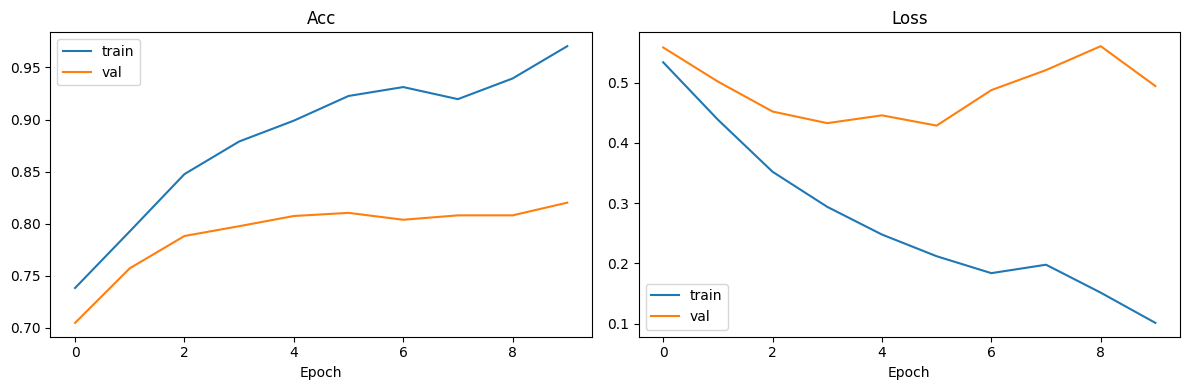


Test accuracy: 0.8082


In [ ]:
# ── learning curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ["acc", "loss"]):
    ax.plot(history[f"train_{metric}"], label="train")
    ax.plot(history[f"val_{metric}"],   label="val")
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.show()

_, test_acc = evaluate(model, test_loader, nn.BCEWithLogitsLoss())
print(f"\nTest accuracy: {test_acc:.4f}")

### Results — context from Pratica 4

| Model | Test Acc |
|---|---|
| Logistic Regression (TF-IDF) | 88.13 % |
| Feed-forward NN (embedding) | ~87 % |
| LSTM | ~84 % |
| **Transformer (this notebook)** | **80.8 %** |

With more tuning (larger model, more epochs, learning-rate schedule, longer sequence length) the Transformer can push further. The key advantage over LSTMs is **parallelism** during training and better handling of long-range dependencies.

---
# Part 2 — Zero-shot and Few-shot with an LLM

Instead of training a model, we **prompt** a large pretrained language model to classify text — no gradient descent needed.

We use the **Groq API** (free tier) with **LLaMA 3.3 70B**.  
Install: `pip install groq`  
Get a key at https://console.groq.com

| Strategy | Labelled examples in prompt | Weight updates |
|---|---|---|
| **Zero-shot** | 0 | None |
| **Few-shot** | K (e.g. 3) | None |

## 2.1 Setup

Get a free API key at https://console.groq.com and paste it below.

In [ ]:
%pip install groq 

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from groq import Groq
import random

GROQ_API_KEY = "your-api-key-here"   # ← replace with your key

SEED         = 42
random.seed(SEED)

N_TEST  = 20    # samples to classify
N_TRAIN = 3     # examples used as few-shot demonstrations

# Load a small subset of IMDb
raw = load_dataset("stanfordnlp/imdb")
train_data = raw["train"].shuffle(seed=SEED).select(range(N_TRAIN))
test_data  = raw["test"].shuffle(seed=SEED).select(range(N_TEST))

print(f"Train examples (demonstrations): {len(train_data)}")
print(f"Test examples to classify:       {len(test_data)}")

Train examples (demonstrations): 3
Test examples to classify:       20


In [ ]:
def call_llm(prompt: str, model="llama-3.3-70b-versatile") -> str:
    client = Groq(api_key=GROQ_API_KEY)
    resp = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        max_tokens=512,
    )
    return resp.choices[0].message.content  #choices[0] because the API can return multiple completions, but we only want the first one.

## 2.2 Zero-shot classification

We describe the task in the prompt without providing any labelled examples.  
The LLM relies entirely on knowledge acquired during pre-training.

In [ ]:
def build_zero_shot_prompt(test_data):
    n = len(test_data)
    prompt  = f"Classify each of the following {n} movie reviews as positive (1) or negative (0).\n"
    prompt += f"Output ONLY a Python list of exactly {n} integers, one per review, in the same order. Example: [1, 0, 1]\n\n"
    for i, sample in enumerate(test_data):
        prompt += f"[{i}] {sample['text'][:300]}\n"
    return prompt

print("=== Zero-shot prompt (first 600 chars) ===")
zs_prompt = build_zero_shot_prompt(test_data)
print(zs_prompt[:600], "...")

=== Zero-shot prompt (first 600 chars) ===
Classify each of the following 20 movie reviews as positive (1) or negative (0).
Output ONLY a Python list of exactly 20 integers, one per review, in the same order. Example: [1, 0, 1]

[0] <br /><br />When I unsuspectedly rented A Thousand Acres, I thought I was in for an entertaining King Lear story and of course Michelle Pfeiffer was in it, so what could go wrong?<br /><br />Very quickly, however, I realized that this story was about A Thousand Other Things besides just Acres. I sta
[1] This is the latest entry in the long series of films with the French agent, O.S.S. 117 (the French answer ...


In [ ]:
zs_response = call_llm(zs_prompt)
print("LLM response:")
print(zs_response)

LLM response:
[0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1]


In [ ]:
import ast
import re as _re

def parse_predictions(response):
    """Extract a Python list of ints from the LLM response."""
    match = _re.search(r"\[[\d,\s]+\]", response, _re.DOTALL)
    if match:
        try:
            return ast.literal_eval(match.group())  #safely evaluate the matched string as a Python literal (list of ints)
        except Exception:
            pass
    return []

def accuracy(preds, targets):
    n = min(len(preds), len(targets))
    correct = sum(p == t for p, t in zip(preds[:n], targets[:n]))
    return correct / len(targets)  # penalise missing predictions

def report(label, preds, targets):
    print(f"Predicted    ({len(preds)}): {preds}")
    print(f"Ground truth ({len(targets)}): {targets}")
    if not preds:
        print("No predictions found — check the LLM response above.")
    elif len(preds) != len(targets):
        acc = accuracy(preds, targets)
        print(f"⚠ Count mismatch ({len(preds)} vs {len(targets)}). "
              f"Accuracy on matched pairs: {acc:.2%}")
    else:
        print(f"{label} accuracy: {accuracy(preds, targets):.2%}")

true_labels = [s["label"] for s in test_data]

zs_preds = parse_predictions(zs_response)
report("Zero-shot", zs_preds, true_labels)

Predicted    (20): [0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1]
Ground truth (20): [1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1]
Zero-shot accuracy: 60.00%


## 2.3 Few-shot classification

We now add a few labelled examples at the beginning of the prompt.  
This is **in-context learning** — the model adapts its behaviour without updating any weights.

In [ ]:
def build_few_shot_prompt(train_data, test_data):
    n = len(test_data)
    prompt  = f"Classify each of the following {n} movie reviews as positive (1) or negative (0).\n"
    prompt += "Here are some labelled examples:\n\n"
    for sample in train_data:
        label = sample["label"]
        prompt += f"Review: {sample['text'][:200]}\nLabel: {label}\n\n"
    prompt += "--------\n"
    prompt += f"Now classify the following {n} reviews.\n"
    prompt += f"Output ONLY a Python list of exactly {n} integers, in the same order. Example: [1, 0, 1]\n\n"
    for i, sample in enumerate(test_data):
        prompt += f"[{i}] {sample['text'][:300]}\n"
    return prompt

fs_prompt = build_few_shot_prompt(train_data, test_data)
print("=== Few-shot prompt (first 800 chars) ===")
print(fs_prompt[:800], "...")

=== Few-shot prompt (first 800 chars) ===
Classify each of the following 20 movie reviews as positive (1) or negative (0).
Here are some labelled examples:

Review: There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. F
Label: 1

Review: This movie is a great. The plot is very true to the book which is a classic written by Mark Twain. The movie starts of with a scene where Hank sings a song with a bunch of kids called "when you stub y
Label: 1

Review: George P. Cosmatos' "Rambo: First Blood Part II" is pure wish-fulfillment. The United States clearly didn't win the war in Vietnam. They caused damage to this country beyond the imaginable and this mo
Label: 0

--------
Now classify the fo ...


In [ ]:
fs_response = call_llm(fs_prompt)
print("LLM response:")
print(fs_response)

LLM response:
[0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1]


In [ ]:
fs_preds = parse_predictions(fs_response)
report(f"Few-shot ({N_TRAIN} demos)", fs_preds, true_labels)

Predicted    (20): [0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1]
Ground truth (20): [1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1]
Few-shot (3 demos) accuracy: 65.00%


## 2.4 Summary

| Approach | Training data | Accuracy (20 samples) |
|---|---|---|
| Trained Transformer (Part 1, full test set) | 25 000 examples | 80.8 % |
| LLM zero-shot (LLaMA 3.3 70B) | 0 | 60.0 % |
| LLM few-shot — 3 demos (LLaMA 3.3 70B) | 3 | 65.0 % |

> Note: the LLM results are on only 20 samples, so they carry high variance. Running on a larger sample would give a more reliable estimate.

**Key takeaways**
- Zero/few-shot LLMs work out of the box with **no labelled data**, but on this small sample they fall behind the trained transformer.
- A few demonstrations (few-shot) already help: 60 % → 65 %.
- Quality depends heavily on **prompt wording** — this is *prompt engineering*.
- Trained models win when data is available and you need reliable, low-latency inference.
- LLMs are most valuable when labelled data is scarce or the task changes frequently.